# 03 · Baseline predictors of pain response

**Outcome:** `no_worsening` = Δ NP1PAIN < +1 over window [−12,0] vs [+6,+18] (per Finding 2 in notebook 01).

In [1]:
source("helpers/pain_helpers.R")
suppressPackageStartupMessages({ library(dplyr); library(tidyr); library(ggplot2); library(broom) })

df <- readRDS(file.path(OUT_OBJ, "pain_long.rds"))
delta <- readRDS(file.path(OUT_OBJ, "pain_delta_responder.rds"))

base_vars <- c("age_at_visit","ageonset","duration_yrs","SEX","fampd","BMI",
               "LEDD","updrs3_score","NHY","NP1PAIN","NP1DPRS","NP1ANXS",
               "gds","stai","scopa")
base <- df %>% dplyr::arrange(PATNO, INFODT_orig) %>%
  dplyr::group_by(PATNO) %>% dplyr::slice_head(n = 1) %>% dplyr::ungroup() %>%
  dplyr::select(PATNO, will_receive_dbs, dplyr::all_of(base_vars))

dat <- delta %>%
  dplyr::mutate(no_worsening = as.integer(delta < 1)) %>%
  dplyr::select(PATNO, will_receive_dbs, delta, no_worsening) %>%
  dplyr::inner_join(base %>% dplyr::select(-will_receive_dbs), by = "PATNO")
cat("Analytic n:", nrow(dat), "\n")
print(dplyr::count(dat, will_receive_dbs, no_worsening))

Warning message:
“package ‘broom’ was built under R version 4.5.2”


Analytic n: 74 


# A tibble: 4 × 3
  will_receive_dbs no_worsening     n
  <lgl>                   <int> <int>
1 FALSE                       0    12
2 FALSE                       1    22
3 TRUE                        0     5
4 TRUE                        1    35


In [2]:
run_uni <- function(arm_label, subset) {
  purrr::map_dfr(base_vars, function(v) {
    sub <- subset[, c("no_worsening", v)] %>% tidyr::drop_na()
    if (nrow(sub) < 15 || dplyr::n_distinct(sub$no_worsening) < 2) {
      return(tibble::tibble(arm = arm_label, predictor = v, n = nrow(sub),
                            or = NA, lci = NA, uci = NA, p = NA))
    }
    fit <- tryCatch(stats::glm(stats::as.formula(paste("no_worsening ~", v)),
                               data = sub, family = "binomial"),
                    error = function(e) NULL)
    if (is.null(fit)) return(tibble::tibble(arm = arm_label, predictor = v, n = nrow(sub),
                                            or = NA, lci = NA, uci = NA, p = NA))
    co <- suppressMessages(broom::tidy(fit, conf.int = TRUE)) %>% dplyr::filter(term == v)
    tibble::tibble(arm = arm_label, predictor = v, n = nrow(sub),
                   or = exp(co$estimate), lci = exp(co$conf.low),
                   uci = exp(co$conf.high), p = co$p.value)
  })
}

uni_dbs    <- run_uni("DBS",       dat %>% dplyr::filter(will_receive_dbs))
uni_nodbs  <- run_uni("Never-DBS", dat %>% dplyr::filter(!will_receive_dbs))
uni_all    <- run_uni("Pooled",    dat)
uni <- dplyr::bind_rows(uni_dbs, uni_nodbs, uni_all)
print(uni)
save_table(uni, "baseline_univariate_or")

# A tibble: 45 × 7
   arm   predictor        n    or    lci    uci      p
   <chr> <chr>        <int> <dbl>  <dbl>  <dbl>  <dbl>
 1 DBS   age_at_visit    40 1.03  0.936    1.13 0.558 
 2 DBS   ageonset        40 1.04  0.939    1.15 0.441 
 3 DBS   duration_yrs    40 1.27  0.627    4.63 0.609 
 4 DBS   SEX             40 0.423 0.0204   3.26 0.463 
 5 DBS   fampd           40 2.48  0.867    8.09 0.0947
 6 DBS   BMI             40 0.980 0.830    1.19 0.821 
 7 DBS   LEDD            40 1.00  0.998    1.00 0.920 
 8 DBS   updrs3_score    35 0.985 0.896    1.08 0.743 
 9 DBS   NHY             21 5.20  0.410  128.   0.216 
10 DBS   NP1PAIN         40 0.696 0.332    1.50 0.325 
# ℹ 35 more rows


Warning message:
“`geom_errobarh()` was deprecated in ggplot2 4.0.0.
ℹ Please use the `orientation` argument of `geom_errorbar()` instead.”


`height` was translated to `width`.


`height` was translated to `width`.


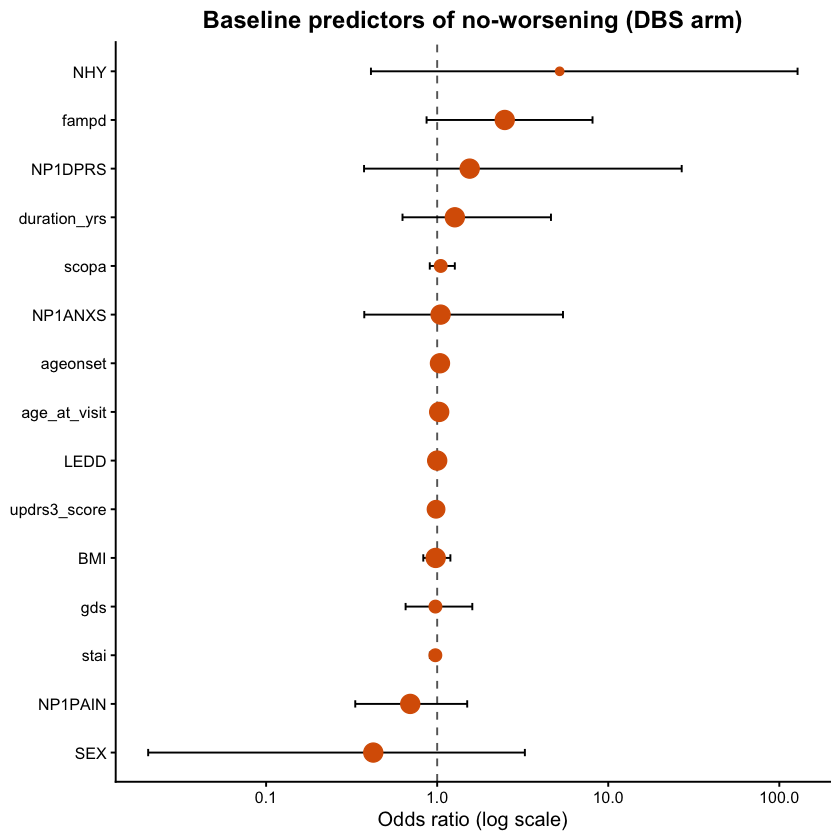

In [3]:
fp <- uni %>% dplyr::filter(arm == "DBS", !is.na(or), is.finite(or), or < 50) %>%
  dplyr::mutate(predictor = forcats::fct_reorder(predictor, or))
p_fp <- ggplot(fp, aes(x = or, y = predictor)) +
  geom_vline(xintercept = 1, linetype = "dashed", colour = "grey40") +
  geom_errorbarh(aes(xmin = lci, xmax = uci), height = 0.15) +
  geom_point(aes(size = n), colour = "#d95f02") +
  scale_x_log10() +
  scale_size_continuous(range = c(2, 5), guide = "none") +
  labs(title = "Baseline predictors of no-worsening (DBS arm)",
       x = "Odds ratio (log scale)", y = NULL) +
  theme_classic(base_size = 12) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5))
p_fp
save_fig(p_fp, "Fig10_baseline_predictors_forest_DBS", width = 7, height = 5)

In [4]:
dat_mv <- dat %>% dplyr::mutate(dbs = as.integer(will_receive_dbs)) %>%
  dplyr::select(no_worsening, dbs, age_at_visit, SEX, LEDD, updrs3_score, NP1PAIN, gds) %>%
  tidyr::drop_na()
cat("Multivariable n:", nrow(dat_mv), "\n")

f_main <- no_worsening ~ dbs + age_at_visit + SEX + LEDD + updrs3_score + NP1PAIN + gds
fit_main <- stats::glm(f_main, data = dat_mv, family = "binomial")
print(suppressMessages(broom::tidy(fit_main, conf.int = TRUE, exponentiate = TRUE)))

f_int <- no_worsening ~ dbs * (age_at_visit + LEDD + updrs3_score + NP1PAIN + gds) + SEX
fit_int <- stats::glm(f_int, data = dat_mv, family = "binomial")
print(suppressMessages(broom::tidy(fit_int, conf.int = TRUE, exponentiate = TRUE)))

cat("\nLR test (does adding DBS interactions help?):\n")
print(stats::anova(fit_main, fit_int, test = "Chisq"))

save_table(suppressMessages(broom::tidy(fit_main, conf.int = TRUE, exponentiate = TRUE)), "mv_main")
save_table(suppressMessages(broom::tidy(fit_int,  conf.int = TRUE, exponentiate = TRUE)), "mv_interactions")

Multivariable n: 39 


Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


...

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


In [5]:
save_object(dat, "baseline_and_delta")
cat("Saved baseline_and_delta.rds (n =", nrow(dat), ")\n")

Saved baseline_and_delta.rds (n = 74 )
